# ETFs: factors taken from the return panel alone

Every model so far has read the feature matrix. [`06_linear`](06_linear.ipynb) gave each column
a coefficient, [`07_gbm`](07_gbm.ipynb) split on them, [`08_tabular_dl`](08_tabular_dl.ipynb)
mixed them in a hidden layer. All three answer the same question - what does this fund's feature
row say about its next return - and they differ only in the shape of the function they are
allowed to write down.

The latent-factor family asks a different question first. Suppose the returns of these hundred
funds are driven by a handful of common movements, and what distinguishes one fund from another
is **how much of each movement it carries**. Then the thing to estimate is the set of movements
and each fund's exposure to them, and a forecast follows from the exposures rather than from a
feature row.

**PCA is the member of that family that uses no features at all.** It takes the matrix of the
forward returns it is asked to forecast over the training window, one column per fund, and finds
the directions along which that matrix varies most. `run_pca_fold` in
[`case_studies/utils/latent_factors/pca.py`](../utils/latent_factors/pca.py) deletes the
characteristic arrays on its first line: whatever `03_financial_features` and
`04_model_based_features` built, this estimator never sees it. That is the point of having it
here. It is the bar the four conditioned members of the family have to clear, and if the return
panel's own covariance structure ranks these funds as well as the feature matrix does, that is a
fact worth knowing before reading the more elaborate models.

**It is available here because an ETF is the same fund throughout.** PCA assigns one loading
vector per column of the return matrix and needs that column to mean the same thing from the
first day of the training window to the last. `config/setup.yaml` declares
`modeling.latent_factors.persistent_entities: true` for this case study, and the runner refuses
PCA outright where that is false. A panel of firms entering and leaving an index cannot promise
it; a fixed list of tickers can.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what a return-panel factor model estimates and what it does not read.
- Work out, from how the forecast is assembled, whether a prediction can change from day to day
  within a fold - and check that against the published predictions rather than assuming it.
- Read a model with no epochs and say why it still publishes a checkpoint.
- Read a population published for every declared label rather than only the traded one.

**Book reference**: Chapter 13, Section 13.3 (PCA for algorithmic trading) and Chapter 14,
Section 14.5 (Bridging economics and statistics with advanced models). Chapter 6, Section 6.7
(Search accounting and run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`02_labels`](02_labels.ipynb) for the two forward returns,
[`05_evaluation`](05_evaluation.ipynb) for the walk-forward folds, and
[`11_latent_factors`](11_latent_factors.ipynb), which introduces the family and says which of its
five members each notebook publishes.

**What it writes**: one training run per label and one complete validation prediction set per
label, in `run_log/registry.db` and under `run_log/training/` and `run_log/predictions/`, grouped
under a population named for this model. The family splits across five notebooks, so each
publishes its own population rather than one shared one.
[`13_model_analysis`](13_model_analysis.ipynb) compares them against the other families and
[`14_backtest`](14_backtest.ipynb) backtests every member and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared ETF return-panel PCA population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""

MODEL_NAME = "pca"

In [3]:
study = open_study("etfs", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which labels, and what the configuration says

Every label whose training menu declares `latent_factors:` is fitted, and both do: `fwd_ret_21d`,
the total return over the 21 trading days after the decision date, and `fwd_ret_5d`, the same
thing over five. The estimator reads none of the 71 feature columns, but it is not blind to the
label: the `returns` matrix that `prepare_panel_data`
([`panel.py`](../utils/latent_factors/panel.py)) fills from the request's own label column is the
one `run_pca_fold` receives as `returns_train`, so the two rows below are two separate fits, each
with its own loadings and premia, rather than one fit scored against two returns. What
changes between them is the panel as well as the scoring, and the number of validation dates.
`LABELS` restricts the run to a subset when you want one.

In [4]:
declared_labels(study, "latent_factors")

('fwd_ret_21d', 'fwd_ret_5d')

`case_studies/config/pca/pca.yaml` declares two things and nothing else. `n_factors` is how many
of the leading directions to keep, and it is the one number that decides how much structure the
model is allowed to find. `checkpoint_interval: 0` says there is no intermediate training state
to publish: PCA is a singular value decomposition of the training window, not a loop over epochs,
so a fold produces one fitted set of loadings and one set of predictions. That is why the plan
below shows a single checkpoint where [`08_tabular_dl`](08_tabular_dl.ipynb) shows eight, and it
is a property of the estimator rather than a reduced setting.

In [5]:
configs = load_model_configs(
    study,
    "latent_factors",
    labels=LABELS or None,
    config_names=[MODEL_NAME],
)
configs.select("label", "config_name", "params")

label,config_name,params
str,str,str
"""fwd_ret_21d""","""pca""","""n_factors=5"""
"""fwd_ret_5d""","""pca""","""n_factors=5"""


`LABELS` narrows what is fitted, and a narrowed run declares a different set of members than the
canonical population does. A population is immutable once written, so such a run must publish
under its own name: on a fresh workspace it would otherwise register an incomplete snapshot under
the canonical one, and where the full population already exists the registry refuses it.

The comparison is against this model's own declared rows rather than the whole `latent_factors`
catalog. The family is split across five notebooks and each publishes one model, so the complete
catalog is five times what this one publishes, and comparing against it would report every
canonical run as narrowed.

In [6]:
declared = load_model_configs(study, "latent_factors", config_names=[MODEL_NAME])
if set(configs.get_column("label")) != set(declared.get_column("label")) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the {declared.height} declared labels, so it cannot "
        "publish the canonical population; pass POPULATION_NAME to give it its own"
    )

### Where this one runs

`config/setup.yaml` puts no device on the latent-factor family, which leaves it to whatever the
machine offers - and a fit that lands on a GPU on one machine and a CPU on another is not the
same computation, because the device is inside the hashed identity rather than recorded beside
it. PCA is a call to `numpy.linalg.svd` and has no GPU implementation at all, so this notebook
declares CPU explicitly. The declaration then travels into the training identity, and a run that
changed it would register beside this one rather than over it.

In [7]:
overrides = {"device": "cpu"}
overrides

{'device': 'cpu'}

## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which fund-date pairs have both a
return and a label, or where the walk-forward folds fall. **Resolving** a request goes and finds
that: it reads the label and feature files, computes the fold boundaries from the walk-forward
parameters in `config/setup.yaml`, and works out the exact set of rows each fit is expected to
predict. It fits nothing, so the plan can be read before any training starts.

Four things to check in it:

- **`eligible_entities` and `eligible_rows` are the panel this estimator decomposes.** The
  entities are the columns of the return matrix and the rows are the fund-date pairs to be
  predicted. `feature_count` is carried for the family and is not read by this member: the
  features decide which rows are eligible, and then the fit sees only returns.
- **`folds` is the same on both rows**, and equals the number of walk-forward splits
  [`05_evaluation`](05_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  is scored once, at the end of the case study; any of it visible here would mean it had been
  used to choose something.
- **`checkpoints` is 1**, for the reason the configuration gives above.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes
into one and what follows from it.

In [8]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides=overrides,
    preview_reductions=PREVIEW_REDUCTIONS,
    notebook="11a_pca",
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "label",
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,i64,i64,i64,i64,i64,datetime[μs],datetime[μs]
"""fwd_ret_21d""","""pca""",71,95,164900,8,1,2015-12-28 00:00:00,2023-11-29 00:00:00
"""fwd_ret_5d""","""pca""",71,95,166372,8,1,2015-12-28 00:00:00,2023-12-21 00:00:00


The plan is also where a short population is visible. A run that fitted fewer labels than the
menu declares would still print an IC table and still register its rows; what it would not do is
announce the gap.

In [9]:
planned_pairs = set(zip(plan["label"], plan["config_name"], strict=True))
requested_pairs = set(zip(configs["label"], configs["config_name"], strict=True))
if planned_pairs != requested_pairs:
    raise RuntimeError(
        "the plan does not match the loaded PCA menu; "
        f"missing {sorted(requested_pairs - planned_pairs)}, "
        f"unexpected {sorted(planned_pairs - requested_pairs)}"
    )
print(f"{len(requested_pairs)} label-configuration pairs")

2 label-configuration pairs


## 3. Fitting the population

`run_model_population` runs every resolved request. For one request it walks the folds, and on
each one:

1. takes that label's forward returns for the funds inside that fold's training window and
   arranges them as a matrix, one column per fund,
2. subtracts each fund's own training-window mean and decomposes what is left, keeping the
   `n_factors` leading directions. Each fund gets a **loading** on each direction - a fixed
   number saying how much of that common movement it carries - and each training day gets a
   **factor return**, the size of that movement on the day,
3. averages each factor return over the training window to get its premium, and predicts a fund's
   validation return as its loadings times those premia.

Step 3 is what makes this a forecast rather than a decomposition: the loadings and the premia
come from the training window only, and the validation days contribute nothing to either. It is
also worth reading carefully for what it does *not* contain - a term that varies with the
validation date. Section 4 checks the published predictions against that reading.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, computed from the resolved specifications and written down before the first fit.
Afterwards every member must exist and be complete, which is what makes the downstream comparison
well defined - [`14_backtest`](14_backtest.ipynb) backtests this population, not whatever
predictions happen to be in the registry.

`SUPERSEDES_POPULATION` names the population hash this run replaces. A population is the set of
prediction identities, so anything that moves a training identity - a changed factor count as
much as a changed label menu - produces a different set under the same name, and the registry
refuses to write it without being told which snapshot it supersedes. It is empty here because
this notebook, run as it stands, reproduces the members already published under that name rather
than changing them, and reproducing a published list is not a replacement. Fill it in when you
have changed something that moves an identity and want the new set to take the name; the error
raised on the attempt tells you which hash to name. A reduced-scale run passes it empty whatever
the default is: a population produced under a reduction is thrown away with the workspace it was
written to, so it has no lineage to extend.

In [10]:
population_name = POPULATION_NAME or f"etfs-{MODEL_NAME}-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=SUPERSEDES_POPULATION or None,
)

published_sets = sum(len(run.predictions) for run in execution.runs)
print(f"{len(execution.runs)} configurations, {published_sets} prediction sets")
print(f"population {population.name}: {len(population.members)} members")

Latent factor CV: 1 models × 8 folds
Log file: case_studies/etfs/run_log/training/81f6afc186d7/.models.a0d37074050646ebb66f55d701993a2b.tmp/latent_factors.log
Scoring: dates=all cadence=- step=1 checkpoint_selection=fixed reporting_epoch=0
  pca (K=5):
    Fold 0: persistent train=2241, val=252, max_N=77


      fold 0: reported_epoch=0, IC=-0.0511, 0.0s


    Fold 1: persistent train=2484, val=252, max_N=77
      fold 1: reported_epoch=0, IC=-0.1819, 0.0s


    Fold 2: persistent train=2484, val=252, max_N=80
      fold 2: reported_epoch=0, IC=+0.0648, 0.0s


    Fold 3: persistent train=2484, val=252, max_N=82
      fold 3: reported_epoch=0, IC=-0.1036, 0.0s


...

    Fold 5: persistent train=2508, val=252, max_N=89
      fold 5: reported_epoch=0, IC=-0.0617, 0.1s


    Fold 6: persistent train=2508, val=252, max_N=89
      fold 6: reported_epoch=0, IC=+0.0334, 0.1s


    Fold 7: persistent train=2508, val=247, max_N=94
      fold 7: reported_epoch=0, IC=+0.0034, 0.1s
    -> reporting epoch=0 (fixed), IC=+0.0101 (2.8s)


  Best: pca (IC=+0.0101)


2 configurations, 2 prediction sets
population etfs-pca-validation-v1: 2 members


A second run of this notebook fits nothing. Every identity is re-derived from the inputs, the
registry already holds the matching rows, and the runner returns the stored result rather than
fitting again - so re-running it unchanged costs the time it takes to read the data. The
latent-factor runner reports no per-fold fitted-or-reused breakdown, unlike the linear and
boosted families, so the counts above are of what the population holds rather than of what this
particular run computed.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("etfs", workspace="~/ml4t-experiments")
configs = load_model_configs(study, "latent_factors", labels=["fwd_ret_5d"], config_names=["pca"])
requests = model_requests(study, configs, overrides={"device": "cpu"})
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-pca-v1")
```

To change the number of factors, edit `case_studies/config/pca/pca.yaml`. That changes this
configuration's identity, so its result registers as a new row beside the old one rather than
replacing it. Give the run its own `population_name`: a name refers to one set of members
permanently, and reusing it for a different set raises.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per label, read back from the registry. `ic_mean` is the **information coefficient**: on
each validation date, rank the funds by the model's prediction, rank them by the return they went
on to earn, correlate the two rankings, and average that daily correlation over the validation
period. It measures whether the model orders the cross-section correctly, on a scale where zero
is no relationship.

`ic_n_days` is how many validation dates produced a defined correlation, and a row measured on
fewer of them is not comparable with one measured on all of them - which is why it is shown
beside the mean rather than left implicit. The two labels have different numbers of scoreable
dates before any model is fitted, because a 21-day forward return runs out of window earlier than
a five-day one does.

The published catalog is checked against the population planned before fitting rather than
against its own row count, because a run that lost a member would otherwise report a shorter
table and nothing else.

In [11]:
catalog = execution.catalog_rows.select(
    "label",
    "config_name",
    "complete",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("label")

if set(catalog.get_column("prediction_hash")) != set(population.members):
    raise RuntimeError("the published catalog differs from the population planned before fitting")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("a partial PCA prediction set cannot pass to backtesting")

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders by whichever
# label it did fit rather than by one that is not there.
ordered_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
print(f"{catalog.height} candidate models across {len(ordered_labels)} labels")
catalog.select("label", "checkpoint_value", "ic_mean", "ic_std", "ic_n_days", "n_folds")

2 candidate models across 2 labels


label,checkpoint_value,ic_mean,ic_std,ic_n_days,n_folds
str,i64,f64,f64,f64,f64
"""fwd_ret_21d""",0,-0.03258,0.088034,1995.0,8.0
"""fwd_ret_5d""",0,0.01004,0.057873,2011.0,8.0


### The prediction does not move within a fold

Read section 3 step 3 again: a fund's predicted return is its loadings times the training-window
factor premia. Both are fitted once per fold and neither depends on the validation date, so every
fund carries one number for the whole of a fold's validation window and the cross-sectional
ranking is fixed until the next fold refits it.

That is a reading of how the forecast is assembled, and it is worth checking against what was
actually published rather than left as an inference. The cell below counts the distinct predicted
values each fund holds within each fold, and raises if any of them is more than one. If a later
version of the estimator gains a time-varying term, this is what tells you, and everything the
rest of this section says about a static ranking stops holding at the same moment.

In [12]:
published = {result.hash: result for run in execution.runs for result in run.predictions}
# The label whose ranking the rest of this section reads, named rather than taken by position:
# `execution.runs` is ordered by how the requests were submitted, not by which label leads.
charted_label = ordered_labels[0]
charted_hash = catalog.filter(pl.col("label") == charted_label).get_column("prediction_hash")[0]
charted = published[charted_hash]
predictions = pl.read_parquet(
    charted.root / "run_log" / "predictions" / charted.hash / "predictions.parquet"
)
per_fund_values = predictions.group_by("fold", "symbol").agg(
    pl.col("prediction").n_unique().alias("distinct_predictions")
)
moving = per_fund_values.filter(pl.col("distinct_predictions") > 1)
if moving.height:
    raise RuntimeError(
        f"{moving.height} fund-fold pairs carry more than one predicted value; the forecast is no "
        "longer constant within a fold and the reading below no longer describes it"
    )
print(
    f"{per_fund_values.height} fund-fold pairs, "
    f"{predictions.n_unique('timestamp')} validation dates, one predicted value each"
)

668 fund-fold pairs, 1995 validation dates, one predicted value each


### How much the ranking changes between folds

A static ranking within a fold leaves one thing to look at: how much it moves when the next fold
refits it on a training window extended by one more block of history. If consecutive folds
produce nearly the same ordering, the model is saying the same thing about these funds throughout
the validation period and its IC is close to one long bet on a fixed ordering. If the ordering
turns over, the additional history is changing which directions dominate the return panel.

The measure is the rank correlation between the predicted cross-sections of consecutive folds,
over the funds both folds predicted. It is a property of the fitted model rather than of its
accuracy: a high value is not good news and a low one is not bad news, and neither is evidence
about the forecast being right.

In [13]:
fold_view = (
    predictions.group_by("fold", "symbol")
    .agg(pl.col("prediction").first())
    .with_columns(rank=pl.col("prediction").rank().over("fold"))
)
folds = sorted(fold_view.get_column("fold").unique().to_list())
turnover = []
for earlier, later in zip(folds, folds[1:], strict=False):
    pair = (
        fold_view.filter(pl.col("fold") == earlier)
        .select("symbol", earlier_rank="rank")
        .join(
            fold_view.filter(pl.col("fold") == later).select("symbol", later_rank="rank"),
            on="symbol",
            how="inner",
        )
    )
    turnover.append(
        {
            "fold_pair": f"{earlier}→{later}",
            "funds": pair.height,
            "rank_correlation": pair.select(pl.corr("earlier_rank", "later_rank")).item(),
        }
    )
# The schema is declared rather than inferred. A run with fewer than two folds - which a
# narrowed population produces - leaves this list empty, and `pl.DataFrame([])` has no columns
# at all, so the chart below fails on a missing `fold_pair` rather than on having nothing to
# draw. Turnover between consecutive folds needs two folds; that is a property of the measure,
# not a failure.
turnover = pl.DataFrame(
    turnover,
    schema={"fold_pair": pl.String, "funds": pl.Int64, "rank_correlation": pl.Float64},
)
turnover

fold_pair,funds,rank_correlation
str,i64,f64
"""0→1""",76,0.617582
"""1→2""",76,0.504589
"""2→3""",79,0.265732
"""3→4""",81,-0.601312
"""4→5""",85,0.355656
"""5→6""",87,-0.453492
"""6→7""",87,0.066584


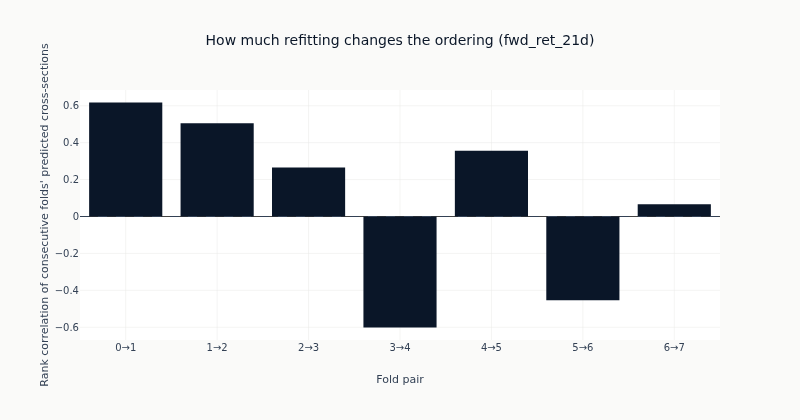

In [14]:
if turnover.height == 0:
    print(
        f"{len(folds)} fold(s) in this population, so there is no consecutive pair to compare "
        "and no turnover to chart."
    )
fig = go.Figure(
    go.Bar(
        x=turnover.get_column("fold_pair").to_list(),
        y=turnover.get_column("rank_correlation").to_list(),
        marker_color=COLORS["blue"],
        showlegend=False,
    )
)
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_yaxes(title_text="Rank correlation of consecutive folds' predicted cross-sections")
fig.update_xaxes(title_text="Fold pair")
fig.update_layout(
    title=f"How much refitting changes the ordering ({charted_label})",
    height=420,
    width=800,
    margin=dict(t=90),
)
# The range is read off the frame rather than asserted, so the alt text stays true of the next run.
_values = turnover.get_column("rank_correlation")
_range = (
    f"values from {_values.min():.2f} to {_values.max():.2f}"
    if turnover.height
    else "no fold pairs, so the chart is empty"
)
show_plotly_with_alt(
    fig,
    "Bar chart of the rank correlation between the predicted cross-sections of consecutive "
    "walk-forward folds, one bar per fold pair, with a dashed zero line. Counted from the frame: "
    f"{turnover.height} fold pairs, {_range}.",
)

### The eight folds behind each average

`ic_mean` above is the equal-weight mean of eight per-fold correlations, and section 5 argues
from how those eight are spread rather than from where they average. A run that reuses a
published fit prints nothing while fitting, so the fold rows are read back from the registry
here - the same rows the mean was taken over - and every per-fold number section 5 quotes comes
from this table.

`n_entities` is how many funds the fold **scored**, which is not the number it fitted on: the
training window reaches further back than the validation block and carries funds that have since
left the panel.

In [15]:
folds_charted = charted.folds()
print(
    f"{charted_label}: {folds_charted.height} folds, "
    f"{folds_charted.filter(pl.col('ic') < 0).height} negative, "
    f"mean {folds_charted.get_column('ic').mean():+.4f}"
)
folds_charted

fwd_ret_21d: 8 folds, 6 negative, mean -0.0326


fold_id,ic,ic_std,n_entities
i64,f64,f64,f64
0,-0.051149,0.320668,77.0
1,-0.181914,0.223695,76.0
2,0.064832,0.192816,79.0
3,-0.10362,0.479211,82.0
4,0.115767,0.302743,86.0
5,-0.003361,0.175347,88.0
6,-0.025022,0.361048,88.0
7,-0.076172,0.330584,92.0


## 5. What to notice

**The forward-return panel's own covariance structure does not rank these funds.** On the primary
label the mean validation IC is **-0.033**, and on the five-day variant **+0.010**. Neither is
evidence of skill, and the negative one is not an inverted signal either: the eight fold ICs
behind it run -0.076, -0.025, -0.003, +0.116, -0.104, +0.065, -0.182, -0.051, so the sign changes
four times and the spread across folds is several times the size of the average. That is the
shape of a quantity centred on nothing.

**The ordering itself reverses when the model is refitted.** The rank correlation between
consecutive folds' predicted cross-sections is negative on two of the seven pairs (-0.45 and
-0.60) and above +0.5 on two others. A fund near the top of one fold's ranking is as likely to
be near the bottom of the next as to stay where it was. The sign ambiguity of a principal
component does not explain this - the premium is averaged from the same fitted factor returns
the loadings came from, so a flipped component flips both and cancels - which leaves the
ordering genuinely turning over as the training window rolls forward.

**The daily IC has far fewer independent observations than `ic_n_days` suggests.** The check
above established that each fund holds one predicted value per fold, so across 1,995 validation
dates this model expresses **eight** rankings, not 1,995. Every date inside a fold is scoring the
same ordering against a different day of returns. `ic_std / sqrt(ic_n_days)` would therefore
understate the uncertainty on `ic_mean` by a wide margin, and that is why no such interval is
computed here. It is a property of any model whose forecast is constant within a fold, and it is
worth carrying into the notebooks that follow, where the forecast moves and the count means more.

**What this establishes for the rest of the family.** PCA is the member that reads none of the
71 feature columns, and it sets the bar the four conditioned members are measured against. That
bar is at zero. A conditioned member that ranks these funds materially better is being helped by
the conditioning rather than by the factor structure, which is the comparison
[`13_model_analysis`](13_model_analysis.ipynb) is arranged to make with every family in front of
it.

**Known limitations.** The matrix decomposed is the label's forward returns, and those overlap:
consecutive rows of the 21-day column share twenty of their twenty-one days. Much of the
covariance structure PCA finds is therefore that overlap rather than same-day co-movement, and
this is not the object a daily-return covariance matrix would be. It is the same target every
conditioned member of the family decomposes, which is what keeps the comparison in
[`11c_conditional_autoencoder`](11c_conditional_autoencoder.ipynb) a comparison about
conditioning rather than about the target. `n_factors` is declared rather than chosen, and
nothing here tests whether a different count would order the cross-section better - that would be
a search, and a search over validation IC is what this notebook is arranged to avoid. The
cross-section narrows as the window rolls forward - the `n_entities` column above falls from 92
funds on the first fold to 77 on the last - so the eight fold ICs are not eight readings of the
same experiment. And every number here is measured on validation folds that have been read many
times over by the time a case study reaches this notebook.

**Next**: [`11b_ipca`](11b_ipca.ipynb) keeps the factor structure and drops the assumption that a
fund's exposure is a fixed number, letting the characteristics this notebook ignored set it
instead.